In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d


In [2]:
df = pd.read_csv("benchmark.csv")

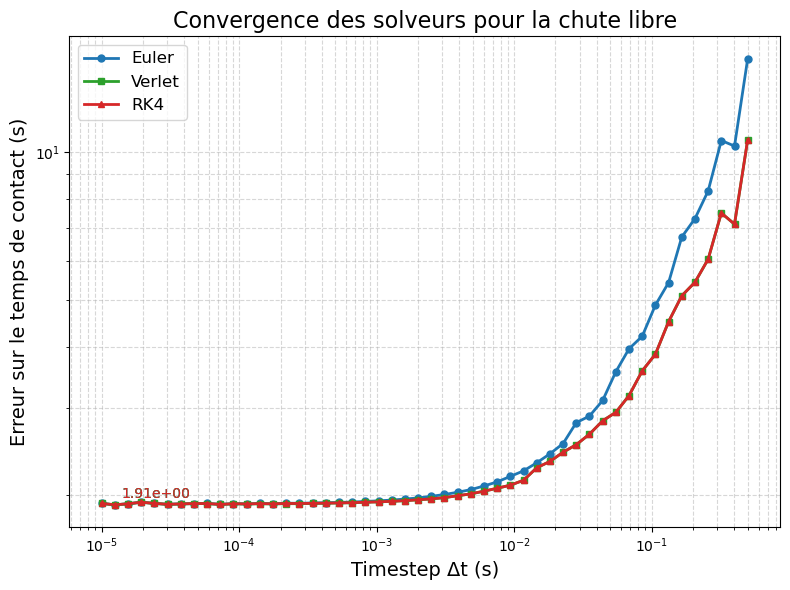

In [ ]:
plt.figure(figsize=(8,6))

solvers = df['solver'].unique()
markers = {'Euler':'o', 'Verlet':'s', 'RK4':'^'}
colors = {'Euler':'tab:blue', 'Verlet':'tab:green', 'RK4':'tab:red'}

for solver in solvers:
    subdf = df[df['solver'] == solver]
    dt = subdf['dt'].values
    error = subdf['error'].values
    plt.plot(dt, error, marker=markers[solver], color=colors[solver], label=solver,
             linewidth=2, markersize=5)

# Axes log-log
plt.xscale('log')
plt.yscale('log')

# Labels et titre
plt.xlabel("Timestep Δt (s)", fontsize=14)
plt.ylabel("Erreur sur le temps de contact (s)", fontsize=14)
plt.title("Convergence des solveurs pour la chute libre", fontsize=16)

# Grille et légende
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)

# Annotations des points d'erreur minimale pour chaque solveur
for solver in solvers:
    subdf = df[df['solver'] == solver]
    min_idx = subdf['error'].idxmin()
    dt_min = subdf.loc[min_idx, 'dt']
    err_min = subdf.loc[min_idx, 'error']
    plt.annotate(f"{err_min:.2e}", xy=(dt_min, err_min),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=10, color=colors[solver])

plt.tight_layout()
plt.show()